In [1]:
!wget https://raw.githubusercontent.com/daniellaeme/ACE-Inhibitor-QSAR/refs/heads/main/data/ace_raw.csv

--2026-04-19 09:43:51--  https://raw.githubusercontent.com/daniellaeme/ACE-Inhibitor-QSAR/refs/heads/main/data/ace_raw.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 90031 (88K) [text/plain]
Saving to: ‘ace_raw.csv’

ace_raw.csv         100%[===================>]  87.92K  --.-KB/s    in 0.02s   

2026-04-19 09:43:51 (5.55 MB/s) - ‘ace_raw.csv’ saved [90031/90031]



In [2]:
! pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 39.4 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np

import os
import requests
from rdkit import Chem

from scipy.stats import mannwhitneyu

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('ace_raw.csv')
df.head()

,canonical_smiles,molecule_chembl_id,pchembl_value,standard_type,standard_units,standard_value,target_chembl_id,type,units,value
0,CC(N[C@H](C)C(=O)N1CCC[C@H]1C(=O)O)C(=O)O,CHEMBL152758,7.05,IC50,nM,90.0,CHEMBL1808,IC50,uM,0.09
1,O=C(CCC(=O)N1CCCC1C(=O)O)NO,CHEMBL291381,4.30,IC50,nM,50000.0,CHEMBL1808,IC50,uM,50.00
2,C[C@@H](NCC(=O)O)C(=O)N1CCC[C@H]1C(=O)O,CHEMBL358439,5.62,IC50,nM,2400.0,CHEMBL1808,IC50,uM,2.40
3,NCCCC[C@H](N[C@@H](CCc1ccccc1)C(=O)O)C(=O)N1CC...,CHEMBL1237,8.92,IC50,nM,1.2,CHEMBL1808,IC50,nM,1.20
4,CC(CCC(=O)N1CCCC1C(=O)O)C(=O)O,CHEMBL293213,NaN,IC50,nM,260000.0,CHEMBL1808,IC50,uM,260.00


In [5]:
df.shape

(764, 10)

In [6]:
display(df[(df['target_chembl_id'] != 'CHEMBL1808') | (df['standard_type'] != 'IC50')].head())

,canonical_smiles,molecule_chembl_id,pchembl_value,standard_type,standard_units,standard_value,target_chembl_id,type,units,value


# Data Cleaning

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 764 entries, 0 to 763
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   canonical_smiles    764 non-null    object 
 1   molecule_chembl_id  764 non-null    object 
 2   pchembl_value       582 non-null    float64
 3   standard_type       764 non-null    object 
 4   standard_units      758 non-null    object 
 5   standard_value      741 non-null    float64
 6   target_chembl_id    764 non-null    object 
 7   type                764 non-null    object 
 8   units               657 non-null    object 
 9   value               741 non-null    float64
dtypes: float64(3), object(7)
memory usage: 59.8+ KB


In [8]:
df.isna().any()

,0
canonical_smiles,False
molecule_chembl_id,False
pchembl_value,True
standard_type,False
standard_units,True
standard_value,True
target_chembl_id,False
type,False
units,True
value,True


In [9]:
# Handling null values
new_df = df.dropna(subset=['canonical_smiles', 'standard_value'])   # Any data without canonical smiles (chemical structure text) and/or standard (IC50) value would not prove to be useful later on.
print(f"Original dataset shape: {df.shape}")
print(f"After dropping nulls: {new_df.shape}")

Original dataset shape: (764, 10)
After dropping nulls: (741, 10)


Raw IC50 values can span several orders of magnitude (from 0.1 nM to over 100,000 nM). Machine learning models struggle with this kind of extreme variance.By converting the IC50 values into pIC50 (the negative base-10 logarithm of the molar concentration), we compress the data into a clean, linear scale—usually falling between 3 and 10. Additionally, this flips the interpretation: higher pIC50 values indicate stronger potency, which is much more intuitive for predictive modeling.

Assuming the standard_value is in nanomolar (nM) units:
$$pIC50 = -log10(IC50 * 10^-9)$$

In [10]:
# Standardise IC50 to pIC50
new_df = new_df.copy()
new_df = new_df[new_df['standard_value'] > 0]                     # Select only where the value is greater than zero.
new_df['pIC50'] = -np.log10(new_df['standard_value'] * 10**-9)    # Multiply the standard_value (in nM) by 10^-9 to convert to M.
new_df.shape
new_df['pIC50'].head()

,pIC50
0,7.045757
1,4.301030
2,5.619789
3,8.920819
4,3.585027


In [11]:
new_df[(new_df['pIC50'] < 1) | (new_df['pIC50'] > 10)]['pIC50']

,pIC50
235,-0.000000
236,-0.000000
550,10.537602


In [12]:
# Cap pIC50 values to prevent outliers
def cap_pIC50(value):
  if value > 10:
    return 10.0
  elif value < 1:
    return 1.0
  else:
    return value

new_df['pIC50'] = new_df['pIC50'].apply(cap_pIC50)
print(new_df[['pIC50', 'pchembl_value']].head())
print(new_df[['pIC50', 'pchembl_value']].info())

      pIC50  pchembl_value
0  7.045757           7.05
1  4.301030           4.30
2  5.619789           5.62
3  8.920819           8.92
4  3.585027            NaN
<class 'pandas.core.frame.DataFrame'>
Index: 741 entries, 0 to 763
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pIC50          741 non-null    float64
 1   pchembl_value  582 non-null    float64
dtypes: float64(2)
memory usage: 17.4 KB
None


This effectively calculates the missing pchembl_values thereby rendering the column useless.

In [13]:
# Dropping unnecessary columns
cols_to_drop = [
    'type', 'value', 'units',           # Original author data
    'standard_type', 'standard_units',  # Quality check done
    'standard_value',                   # Converted to pIc50
    'target_chembl_id',                  # Quality check done
    'pchembl_value'
]
new_df = new_df.drop(columns=cols_to_drop)
print(new_df.head())
print(new_df.shape)

                                    canonical_smiles molecule_chembl_id  \
0          CC(N[C@H](C)C(=O)N1CCC[C@H]1C(=O)O)C(=O)O       CHEMBL152758   
1                        O=C(CCC(=O)N1CCCC1C(=O)O)NO       CHEMBL291381   
2            C[C@@H](NCC(=O)O)C(=O)N1CCC[C@H]1C(=O)O       CHEMBL358439   
3  NCCCC[C@H](N[C@@H](CCc1ccccc1)C(=O)O)C(=O)N1CC...         CHEMBL1237   
4                     CC(CCC(=O)N1CCCC1C(=O)O)C(=O)O       CHEMBL293213   

      pIC50  
0  7.045757  
1  4.301030  
2  5.619789  
3  8.920819  
4  3.585027  
(741, 3)


In [14]:
new_df['pIC50'].describe()

,pIC50
count,741.000000
mean,6.384457
std,1.831963
min,1.000000
25%,5.065502
50%,6.657577
75%,7.853872
max,10.000000


In [15]:
new_df.duplicated().any()

np.True_

In [16]:
duplicated_rows = new_df[new_df.duplicated(subset=['canonical_smiles'], keep=False)]
duplicated_smiles = duplicated_rows['canonical_smiles'].unique().tolist()
print(f"Number of duplicated canonical smiles: {len(duplicated_smiles)}")
print(f"List of duplicated canonical smiles: {duplicated_smiles}")


Number of duplicated canonical smiles: 48
List of duplicated canonical smiles: ['CC(N[C@H](C)C(=O)N1CCC[C@H]1C(=O)O)C(=O)O', 'C[C@@H](NCC(=O)O)C(=O)N1CCC[C@H]1C(=O)O', 'NCCCC[C@H](N[C@@H](CCc1ccccc1)C(=O)O)C(=O)N1CCC[C@H]1C(=O)O', 'C[C@H](N[C@@H](CCc1ccccc1)C(=O)O)C(=O)N1CCC[C@H]1C(=O)O', 'C[C@H](CS)C(=O)N1CCC[C@H]1C(=O)O', 'NCCCCC(NC(=O)C1CCC1)C(=O)NC(Cc1ccccc1)C(=O)CCC(=O)N1CCCC1C(=O)O.O=C(O)C(F)(F)F', 'C[C@H](NC(=O)[C@@H](S)Cc1ccccc1)C(=O)N1CCC[C@H]1C(=O)O', 'O=C(O)CN1C(=O)[C@@H](NC(=O)[C@@H](S)Cc2ccccc2)CCc2ccccc21', 'C[C@H](NC(=O)[C@@H](N)Cc1ccccc1)C(=O)N1CCC[C@H]1C(=O)O', 'CCOC(=O)[C@H](CCc1ccccc1)N[C@@H](C)C(=O)N1CCC[C@H]1C(=O)O', 'CCOC(=O)[C@H](CCc1ccccc1)N[C@@H](C)C(=O)N1Cc2ccccc2C[C@H]1C(=O)O', 'C[C@H](N[C@@H](CCc1ccccc1)C(=O)O)C(=O)N1Cc2ccccc2C[C@H]1C(=O)O', 'O=C(N[C@@H](Cc1ccccc1)C(=O)CCC(=O)N1CCC[C@H]1C(=O)O)c1ccccc1', 'CC(CS)C(=O)N1Cc2ccccc2C1C(=O)O', 'CCOC(=O)[C@H](CCc1ccccc1)N[C@@H](C)C(=O)N1Cc2cc(OC)c(OC)cc2C[C@H]1C(=O)O', 'CC(CS)C(=O)N1CCc2ccccc2C1C(=O)O', 'O=C(O)CN1C

In [17]:
# Group by SMILES and calculate mean of pIC50
unique_df = new_df.groupby('canonical_smiles', as_index=False).agg({
    'molecule_chembl_id': 'first',
    'pIC50': 'mean'
})
print(f"With duplicates: {new_df.shape}")
print(f"Without duplicates: {unique_df.shape}")

With duplicates: (741, 3)
Without duplicates: (624, 3)


For binary classification, the bioactivity thresholds are as follows:
*   Actives: IC50 < 1000nM(pIC50 >= 6.0)
*   Intermediate: IC50 1000nM  - 10000nM(pIC50 5.0 - 6.0)
*   Inactives: IC50 > 10000nM (pIC50 <= 5.0)




In [18]:
# Define binary classification bsed on pIC50
def classify_bioactivity(pIC50):
  if pIC50 >= 6.0:
    return 'Active'
  elif pIC50 <= 5.0:
    return 'Inactive'
  else:
    return 'Intermediate'

unique_df['class'] = unique_df['pIC50'].apply(classify_bioactivity)
print(unique_df.head())

# Drop Intermediate columns to enforce binary classification
final_df = unique_df[unique_df['class'] != 'Intermediate'].reset_index(drop=True)
print(final_df.head())
print(final_df.shape)

                                    canonical_smiles molecule_chembl_id  \
0  C=C1N[C@@H](CC(C)C)C(=O)N2CCC[C@H]2C(=O)N[C@@H...      CHEMBL5420290   
1  CC(=O)CN1C(=O)/C(=N\C(=S)NCc2cc3ccccc3cc2O)c2c...      CHEMBL4159339   
2  CC(=O)C[C@@]1(O)C(=O)C2=C3O[C@H](C)C(C)(C)[C@]...      CHEMBL5207978   
3  CC(=O)C[C@]1(O)C(=O)C2=C3O[C@H](C)C(C)(C)[C@]3...      CHEMBL5177969   
4  CC(=O)N1C(=O)/C(=N\C(=S)NCc2cc3ccccc3cc2O)c2cc...      CHEMBL4167651   

      pIC50         class  
0  7.397940        Active  
1  6.950782        Active  
2  5.508638  Intermediate  
3  4.947691      Inactive  
4  7.971836        Active  
                                    canonical_smiles molecule_chembl_id  \
0  C=C1N[C@@H](CC(C)C)C(=O)N2CCC[C@H]2C(=O)N[C@@H...      CHEMBL5420290   
1  CC(=O)CN1C(=O)/C(=N\C(=S)NCc2cc3ccccc3cc2O)c2c...      CHEMBL4159339   
2  CC(=O)C[C@]1(O)C(=O)C2=C3O[C@H](C)C(C)(C)[C@]3...      CHEMBL5177969   
3  CC(=O)N1C(=O)/C(=N\C(=S)NCc2cc3ccccc3cc2O)c2cc...      CHEMBL4167651   
4     

In [19]:
print(f"Original shape: {df.shape}")
print(f"Final shape for modeling: {final_df.shape}")
print("\nClass Distribution:")
print(final_df['class'].value_counts())

Original shape: (764, 10)
Final shape for modeling: (553, 4)

Class Distribution:
class
Active      379
Inactive    174
Name: count, dtype: int64


In [20]:
# Save clean dataset
final_df.to_csv('ace_clean.csv', index=False)
print("...Dataset Clean and Ready for EDA...\n" +
      "...Saved to ace_clean.csv...")

...Dataset Clean and Ready for EDA...
...Saved to ace_clean.csv...


# Physicochemical Feature Engineering

In [21]:
df = pd.read_csv('ace_clean.csv')
df.head()

,canonical_smiles,molecule_chembl_id,pIC50,class
0,C=C1N[C@@H](CC(C)C)C(=O)N2CCC[C@H]2C(=O)N[C@@H...,CHEMBL5420290,7.397940,Active
1,CC(=O)CN1C(=O)/C(=N\C(=S)NCc2cc3ccccc3cc2O)c2c...,CHEMBL4159339,6.950782,Active
2,CC(=O)C[C@]1(O)C(=O)C2=C3O[C@H](C)C(C)(C)[C@]3...,CHEMBL5177969,4.947691,Inactive
3,CC(=O)N1C(=O)/C(=N\C(=S)NCc2cc3ccccc3cc2O)c2cc...,CHEMBL4167651,7.971836,Active
4,CC(=O)N1CCCC1C(NC(C)C(=O)N1CCCC1C(=O)O)C(=O)O,CHEMBL342652,8.026872,Active


In [22]:
# Referencing previous code to calculate Lipinski's Rule of 5
url = "https://raw.githubusercontent.com/daniellaeme/My-Chem-Bioinformatics-Toolkit/refs/heads/main/%5B2%5D_drug-likeness-predictor/utils.py"

# Download file if not already in this colab environment
if not os.path.exists('utils.py'):
  r = requests.get(url)
  with open('utils.py', 'w') as f:
    f.write(r.text)
  print("utils.py successfully downloaded.")

from utils import get_descriptors

def smiles_to_descriptors(smiles):
  mol = Chem.MolFromSmiles(smiles)
  if mol:
    return get_descriptors(mol)
  return {"MW":None, "LogP":None, "HBD":None, "HBA":None, "TPSA":None, "RotBonds":None, "QED":None}

print("Calculating descriptors...")
descriptors_df = df['canonical_smiles'].apply(smiles_to_descriptors).apply(pd.Series)
df = pd.concat([df, descriptors_df], axis=1)
df.head()

utils.py successfully downloaded.
Calculating descriptors...


,canonical_smiles,molecule_chembl_id,pIC50,class,MW,LogP,HBD,HBA,TPSA,RotBonds,QED
0,C=C1N[C@@H](CC(C)C)C(=O)N2CCC[C@H]2C(=O)N[C@@H...,CHEMBL5420290,7.397940,Active,2113.578,-8.52266,28.0,31.0,811.63,26.0,0.023625
1,CC(=O)CN1C(=O)/C(=N\C(=S)NCc2cc3ccccc3cc2O)c2c...,CHEMBL4159339,6.950782,Active,417.490,3.34480,2.0,4.0,82.00,4.0,0.636535
2,CC(=O)C[C@]1(O)C(=O)C2=C3O[C@H](C)C(C)(C)[C@]3...,CHEMBL5177969,4.947691,Inactive,414.410,1.25962,3.0,8.0,138.20,2.0,0.615058
3,CC(=O)N1C(=O)/C(=N\C(=S)NCc2cc3ccccc3cc2O)c2cc...,CHEMBL4167651,7.971836,Active,403.463,3.30230,2.0,4.0,82.00,2.0,0.641871
4,CC(=O)N1CCCC1C(NC(C)C(=O)N1CCCC1C(=O)O)C(=O)O,CHEMBL342652,8.026872,Active,355.391,-0.49580,3.0,5.0,127.25,6.0,0.586183


In [23]:
df.isna().any()

,0
canonical_smiles,False
molecule_chembl_id,False
pIC50,False
class,False
MW,False
LogP,False
HBD,False
HBA,False
TPSA,False
RotBonds,False


In [24]:
df.shape

(553, 11)

In [25]:
df = df.dropna(subset=['MW'])
df.shape

(553, 11)

# Statistical Validation

Statistical Validation using Mann-Whitney U Test, a non-parametric test.

To prevent human bias, the chemical descriptors separating active ACE inhibitors from inactives are mathematically proven. Because chemical data (like Hydrogen Bond counts) is discrete and often skewed, we cannot use a parametric T-test.

This test ranks all molecules regardless of their exact values and calculates the $U$ statistic:
$$U = R - \frac{n(n+1)}{2}$$
*(where $R$ is the sum of the ranks in the sample, and $n$ is the number of observations).*

**Hypothesis Testing:**
* **Null Hypothesis ($H_0$):** There is no significant difference in the descriptor values between Actives and Inactives.
* **Alternative Hypothesis ($H_1$):** There is a statistically significant difference.
* **Significance Level ($\alpha$):** 0.05



In [26]:
# Statistical Hypothesis Testing
descriptors = ['MW', 'LogP', 'HBD', 'HBA', 'TPSA', 'RotBonds', 'QED']

print("Mann-Whitney U Test Results (Active vs Inactive)\n" + "-"*50)

stats_results = []

for desc in descriptors:
  # Separate actives from inactives
  actives = df[df['class']=='Active'][desc]
  inactives = df[df['class']=='Inactive'][desc]

  stat, p_value = mannwhitneyu(actives, inactives, alternative='two-sided')

  # Determine if the descriptor is statistically significant (alpha = 0.05)
  significance = "Significant ***" if p_value < 0.05 else "Not Significant"
  print(f"{desc:>10} | p-value: {p_value:.4e} | {significance}")
  stats_results.append({'Descriptor': desc, 'p-value': p_value, 'Significance': significance})

stats_df = pd.DataFrame(stats_results)
stats_df.to_csv('ace_mannwhitneyu_results.csv', index=False)
print('...Results saved to ace_mannwhitneyu_results.csv...')

Mann-Whitney U Test Results (Active vs Inactive)
--------------------------------------------------
        MW | p-value: 5.3759e-35 | Significant ***
      LogP | p-value: 2.3485e-13 | Significant ***
       HBD | p-value: 2.5955e-03 | Significant ***
       HBA | p-value: 3.9723e-13 | Significant ***
      TPSA | p-value: 7.1101e-03 | Significant ***
  RotBonds | p-value: 5.8167e-22 | Significant ***
       QED | p-value: 6.3285e-02 | Not Significant
...Results saved to ace_mannwhitneyu_results.csv...


**Conclusion:**
With the exception of general drug-likeness (QED), all Lipinski and Veber descriptors yielded a $p$-value < 0.05. We reject the null hypothesis for these features, confirming they are statistically valid parameters to feed into our machine learning model.

# Chemical Space Analysis

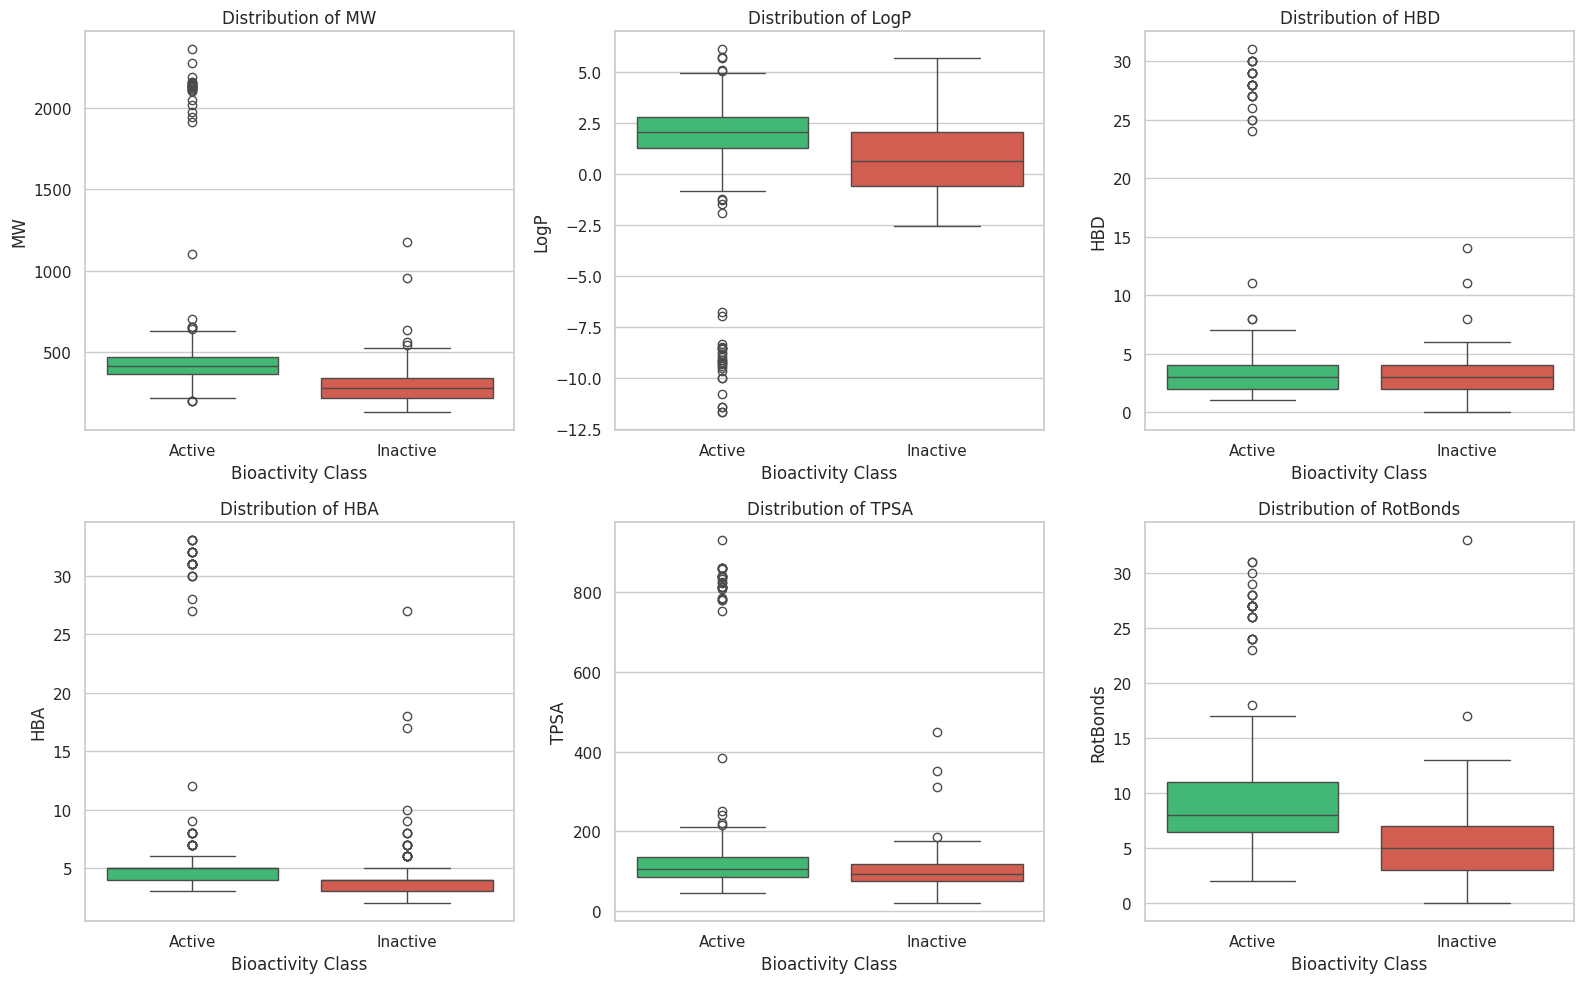

In [27]:
# BoxPlot Distribution
sns.set_theme(style='whitegrid')

significant_descriptors = [d for d in descriptors if d != 'QED']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
custom_palette = {'Active':'#2ecc71', 'Inactive':'#e74c3c'}     # Assigns green for actives and red for inactives for a clear distinction

for i, descriptor in enumerate(significant_descriptors):
  sns.boxplot(
      x='class',
      y=descriptor,
      data=df,
      ax=axes[i],
      palette=custom_palette,
      hue='class'               # Necessary with palette
  )
  axes[i].set_title(f"Distribution of {descriptor}")
  axes[i].set_xlabel('Bioactivity Class')
  axes[i].set_ylabel(descriptor)

plt.tight_layout()

plt.savefig('descriptor_boxplots.png', dpi=300)
plt.show()

I calculated the drug-likeness descriptors first to establish my feature set. Instead of blindly plotting every single feature and guessing if the visual differences were meaningful, I applied a Mann-Whitney U test. This gave me a mathematical, objective baseline to identify which chemical properties actually separate active and inactive compounds. Once the math highlights the statistically significant features, I would generate targeted visualizations.

**Insights**:
1. **MW & RotBonds**:
The median and overall height of the MW and RotBonds actives are noticeably higher than the inactives.
**Validation**: The human ACE has been proven to contain deep, narrow binding channels that require large and flexible inhibitors whereas, small, rigid molecules physically cannot effectively bind to the necessary interaction points.

2. **HBA, HBD and TPSA**:
These contain extreme outliers in the active class.
**Validation**: Researchers used the heavy, complex viper venom peptides as the template to design the first oral ACE inhibitors. These peptides inherently have massive HBA, HBD, and TPSA scores compared to standard synthetic drugs.

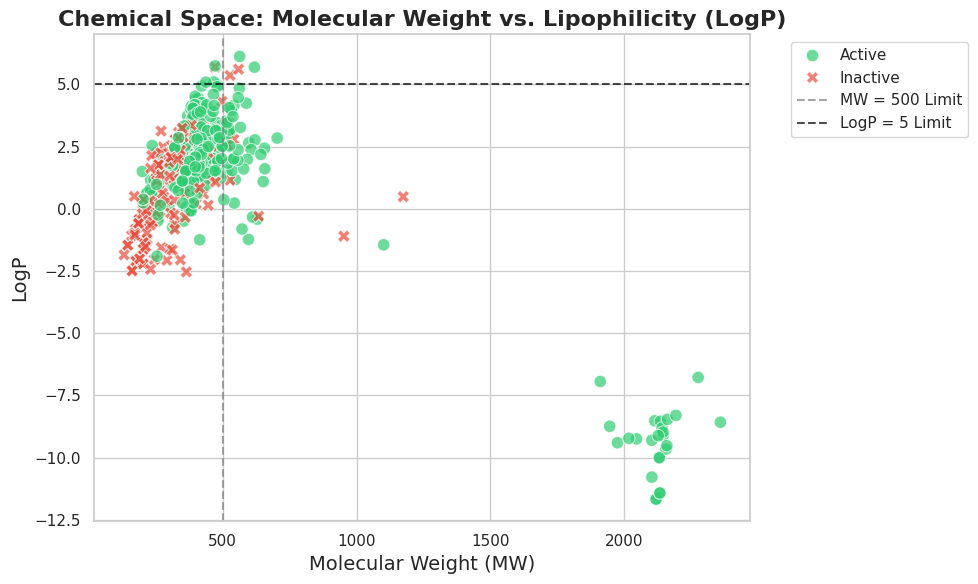

In [28]:
# Scatterplots
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='MW',
    y='LogP',
    hue='class',
    data=df,
    alpha=0.7,                                # Slight transparency to see overlapping points
    palette=custom_palette,
    style='class',                            # Necessary to see changes done by marker
    markers={'Active': 'o', 'Inactive': 'X'}, # Circlos for actives, X's for inactives
    s=80                                      # Marker size
)

# Add dashed lines to visually set Lipinski's thresholds
plt.axvline(x=500, color='gray', linestyle='--', alpha=0.7, label='MW = 500 Limit')
plt.axhline(y=5, color='black', linestyle='--', alpha=0.7, label='LogP = 5 Limit')

plt.title('Chemical Space: Molecular Weight vs. Lipophilicity (LogP)', fontsize=16, fontweight='bold')
plt.xlabel('Molecular Weight (MW)', fontsize=14)
plt.ylabel('LogP', fontsize=14)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')    # Move the legend out of the scatterplot

plt.tight_layout()
plt.savefig('chemical_space_scatter.png', dpi=300)
plt.show()

**Insights**:

1. **The Lipinski Exemption**: A dense cluster of green Active dots pushes far to the right of the dashed MW = 500 limit line.
**Validation**: Because ACE inhibitors mimic natural peptides, they are actively pumped into the bloodstream by intestinal peptide transporters (like PEPT1). Therefore, they can be much larger and more polar than Lipinski’s rules traditionally allow and still function perfectly as oral drugs.

2. **A heavy concentration of red Inactive 'X's clustered where both Molecular Weight and LogP are very low**: Very small (low MW) and highly water-soluble (low LogP) molecules are too simple and lack the necessary "grease" to bind tightly, resulting in weak (inactive) compounds.
**Validation**: Fragments (typically under 250 Da) yields molecules that only have very weak binding affinities.

In [29]:
df.to_csv('ace_eda_final.csv', index=False)
print("...Saved to ace_eda_final.csv..." +
      "...Dataset Ready for Modeling...\n")

...Saved to ace_eda_final.csv......Dataset Ready for Modeling...



REFERENCES
1. https://www.kaggle.com/discussions/general/419726
2. Chicco D, Sichenze A, Jurman G. A simple guide to the use of Student's t-test, Mann-Whitney U test, Chi-squared test, and Kruskal-Wallis test in biostatistics. BioData Min. 2025 Aug 20;18(1):56. doi: 10.1186/s13040-025-00465-6. PMID: 40835959; PMCID: PMC12366075.

3. Natesh, R., Schwager, S., Sturrock, E. et al. Crystal structure of the human angiotensin-converting enzyme–lisinopril complex. Nature 421, 551–554 (2003). https://doi.org/10.1038/nature01370

4. Cushman DW, Ondetti MA. History of the design of captopril and related inhibitors of angiotensin converting enzyme. Hypertension. 1991 Apr;17(4):589-92. doi: 10.1161/01.hyp.17.4.589. PMID: 2013486.

5. Lipinski CA, Lombardo F, Dominy BW, Feeney PJ. Experimental and computational approaches to estimate solubility and permeability in drug discovery and development settings. Adv Drug Deliv Rev. 2001 Mar 1;46(1-3):3-26. doi: 10.1016/s0169-409x(00)00129-0. PMID: 11259830.

6. Erlanson DA, McDowell RS, O'Brien T. Fragment-based drug discovery. J Med Chem. 2004 Jul 1;47(14):3463-82. doi: 10.1021/jm040031v. PMID: 15214773.

**Objectives Achieved:**
1. **Data Cleaning:** Successfully handled missing values, resolved duplicate molecular assays by averaging pIC50 scores, and established strict binary classification thresholds (Actives vs. Inactives).
2. **Feature Engineering (Physicochemical):** Leveraged RDKit to extract drug-likeness descriptors (Lipinski's Rule of 5, Veber's rules).
3. **Statistical Validation:** Deployed non-parametric Mann-Whitney U testing to mathematically prove that physical properties (specifically Molecular Weight and Rotatable Bonds) significantly differentiate active ACE inhibitors from inactive decoys.
4. **Chemical Space Analysis:** Visualized the dataset, confirming that active compounds align with the known biological requirements of the ACE target (large, flexible peptidomimetics) rather than traditional small-molecule Lipinski constraints.

**Next Steps:**
In the next notebook (`03_Model_Building.ipynb`), we will load `ace_enriched_data.csv`, translate the chemical structures into Morgan Fingerprints (binary vectors), and train our machine learning classifiers.